In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/hearing_test.csv')

In [3]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [4]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [5]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='test_result', ylabel='count'>

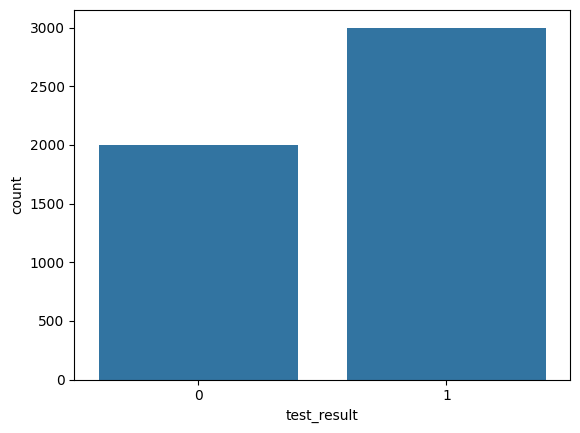

In [6]:
sns.countplot(data=df, x='test_result')

<Axes: xlabel='test_result', ylabel='age'>

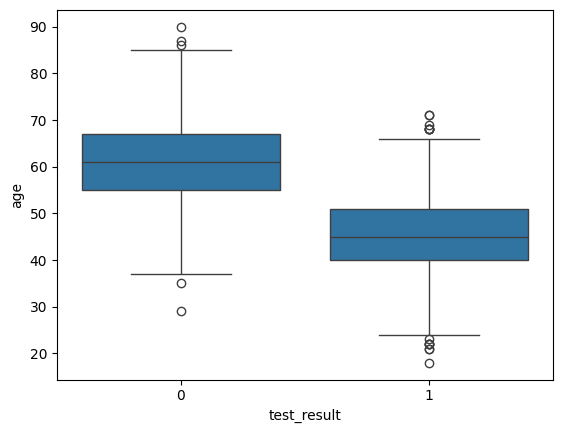

In [7]:
sns.boxplot(x='test_result', y='age', data=df)

<Axes: xlabel='test_result', ylabel='physical_score'>

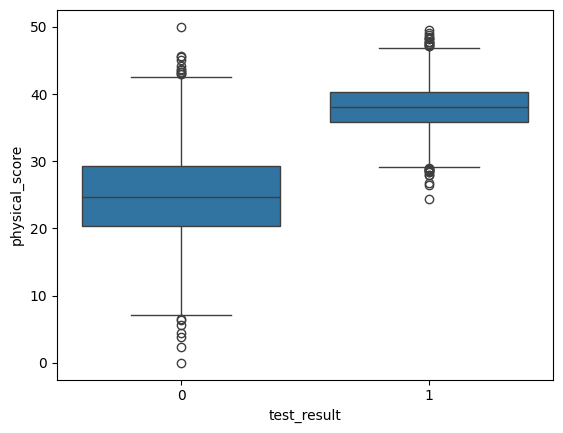

In [8]:
sns.boxplot(x='test_result', y='physical_score', data=df)

<Axes: xlabel='age', ylabel='physical_score'>

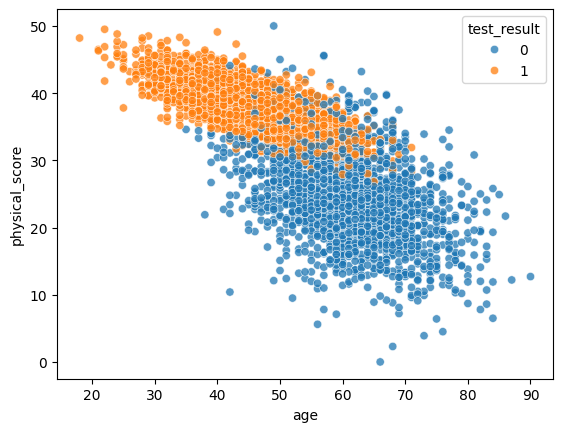

In [9]:
sns.scatterplot(x='age', y='physical_score', data=df, hue='test_result', alpha=0.75)

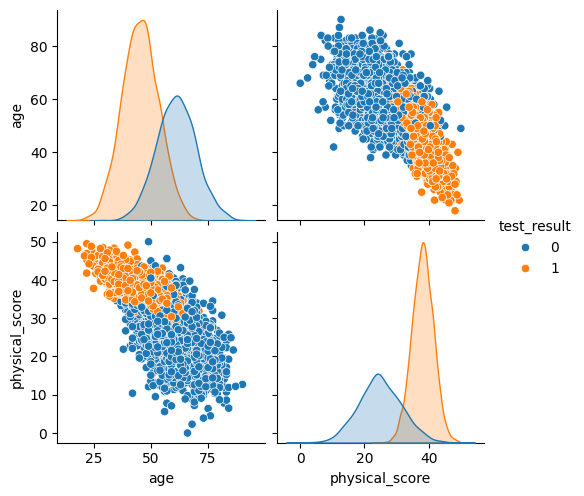

In [10]:
sns.pairplot(df, hue='test_result')

<Axes: >

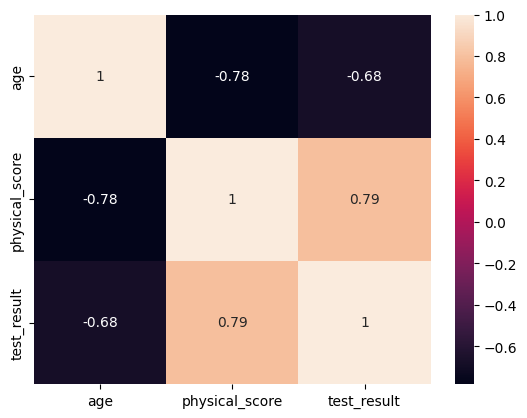

In [11]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='physical_score', ylabel='test_result'>

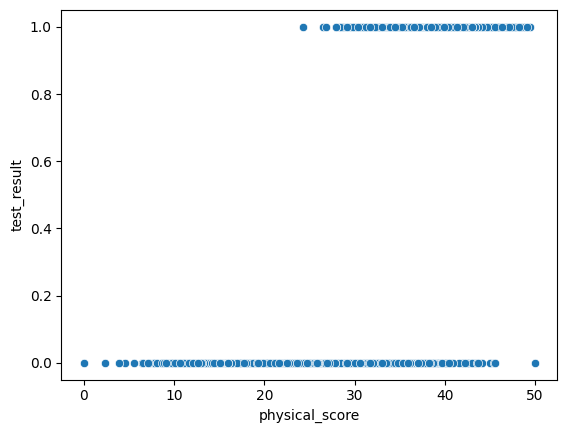

In [12]:
sns.scatterplot(x='physical_score', y='test_result', data=df)

<Axes: xlabel='test_result', ylabel='physical_score'>

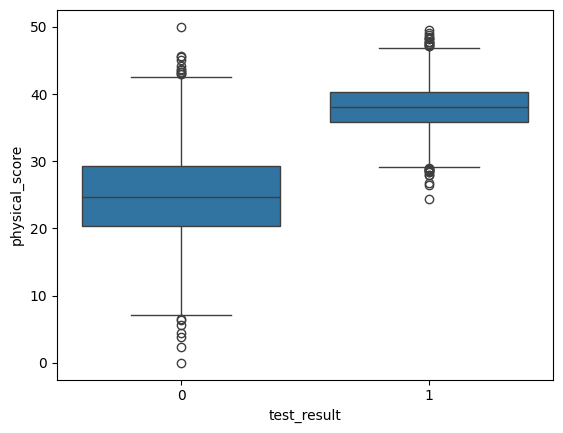

In [13]:
sns.boxplot(x='test_result', y='physical_score', data=df)

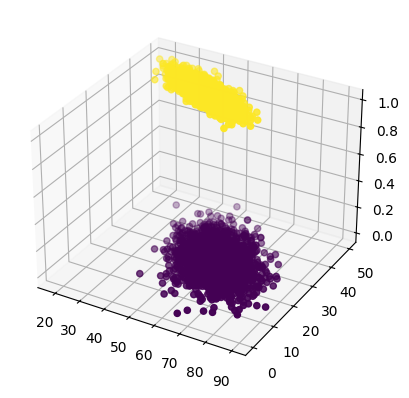

In [14]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(df['age'], df['physical_score'], df['test_result'], c=df['test_result'])

In [15]:
X = df.drop('test_result', axis=1)
y = df['test_result']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [18]:
scaler = StandardScaler()

In [19]:
scaled_X_train = scaler.fit_transform(X_train)

In [20]:
scaled_X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
log_model = LogisticRegression()

In [23]:
log_model.fit(scaled_X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
log_model.coef_

array([[-0.95017725,  3.46148946]])

In [25]:
y_pred = log_model.predict(scaled_X_test)

In [26]:
y_pred

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [27]:
y_pred_proba = log_model.predict_proba(scaled_X_test)

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:
y_test

1718    1
2511    1
345     0
2521    1
54      0
       ..
4770    1
188     1
3335    0
4583    0
3208    0
Name: test_result, Length: 500, dtype: int64

In [30]:
y_pred = log_model.predict(scaled_X_test)

In [31]:
accuracy_score(y_test, y_pred)

0.93

In [32]:
confusion_matrix(y_test, y_pred) 

array([[172,  21],
       [ 14, 293]])

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay


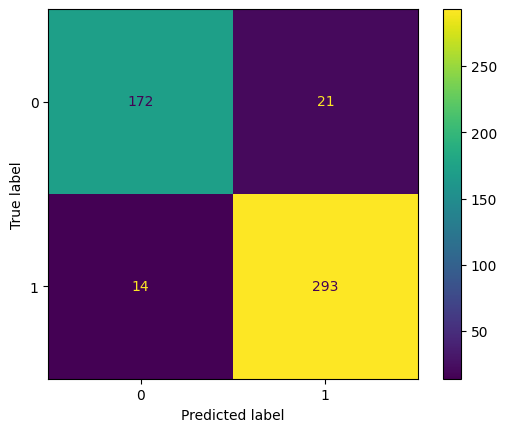

In [34]:
ConfusionMatrixDisplay.from_estimator(log_model, scaled_X_test, y_test)

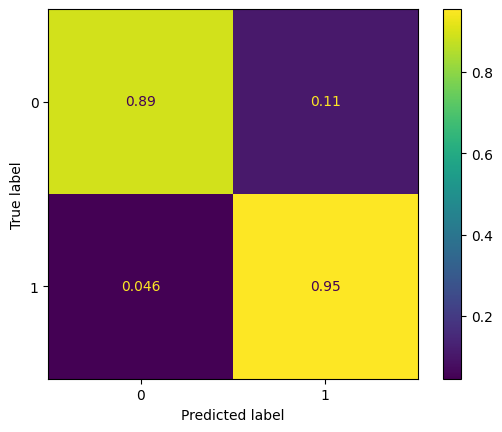

In [35]:
ConfusionMatrixDisplay.from_estimator(log_model, scaled_X_test, y_test, normalize="true")

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



In [37]:
from sklearn.metrics import recall_score, precision_score

In [38]:
precision_score(y_test, y_pred)

0.9331210191082803

In [39]:
recall_score(y_test, y_pred)

0.9543973941368078

In [40]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

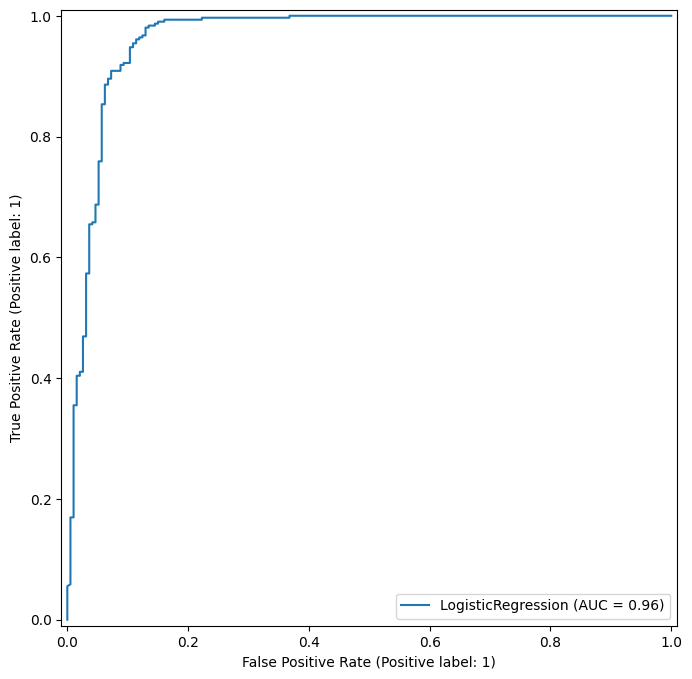

In [41]:
fig, ax = plt.subplots(figsize=(12,8),dpi=100)
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test, ax=ax)

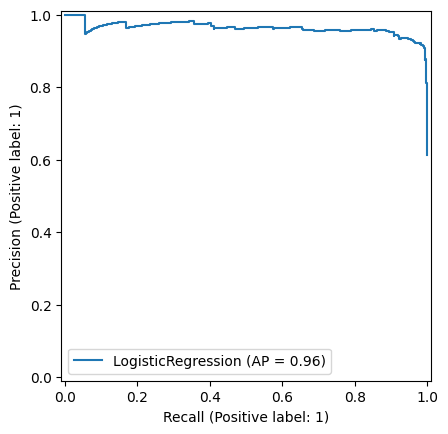

In [42]:
PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test)

In [43]:
log_model.predict_proba(scaled_X_test)[0]

array([0.02380517, 0.97619483])

In [44]:
y_test[0]

np.int64(1)